In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r'D:\Downloads\customer_behavior_eda.csv')

In [5]:
df.head()

,customer_id,signup_date,region,acquisition_channel,segment,age,annual_income_egp,monthly_spend_egp,orders_last_6m,avg_order_value_egp,satisfaction_score,support_tickets,discount_rate,website_visits_last_30d,is_active,churned
0,CUST-10000,2023-04-13,Mansoura,Web,Bronze,53,"216,154",2209.15,6,334.40,NaN,7,0.36,9,Yes,Yes
1,CUST-10001,NaN,Mansoura,Mobile App,Silver,64,"232,796",2558.02,7,409.97,4.6,3,0.10,18,Yes,No
2,CUST-10002,2023-09-28,Giza,Mobile App,Bronze,38,"137,301",2462.59,9,286.26,3.8,3,0.37,7,Yes,No
3,CUST-10003,2023-04-17,Giza,Mobile App,Bronze,38,80006.0,1817.51,8,250.25,4.1,2,0.22,12,Yes,No
4,CUST-10004,2023-03-13,Alexandria,Mobile App,Gold,44,225943.0,3183.25,6,519.34,4.5,1,0.10,7,Yes,No


In [6]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 532 entries, 0 to 531
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              532 non-null    str    
 1   signup_date              522 non-null    str    
 2   region                   517 non-null    str    
 3   acquisition_channel      532 non-null    str    
 4   segment                  532 non-null    str    
 5   age                      532 non-null    int64  
 6   annual_income_egp        500 non-null    str    
 7   monthly_spend_egp        532 non-null    float64
 8   orders_last_6m           532 non-null    int64  
 9   avg_order_value_egp      512 non-null    float64
 10  satisfaction_score       506 non-null    float64
 11  support_tickets          532 non-null    int64  
 12  discount_rate            532 non-null    float64
 13  website_visits_last_30d  532 non-null    int64  
 14  is_active                532 non-null

In [7]:
df.isna().sum().sort_values(ascending=False)

annual_income_egp          32
satisfaction_score         26
avg_order_value_egp        20
region                     15
signup_date                10
segment                     0
acquisition_channel         0
customer_id                 0
monthly_spend_egp           0
age                         0
orders_last_6m              0
support_tickets             0
discount_rate               0
website_visits_last_30d     0
is_active                   0
churned                     0
dtype: int64

In [8]:
df.columns

Index(['customer_id', 'signup_date', 'region', 'acquisition_channel',
       'segment', 'age', 'annual_income_egp', 'monthly_spend_egp',
       'orders_last_6m', 'avg_order_value_egp', 'satisfaction_score',
       'support_tickets', 'discount_rate', 'website_visits_last_30d',
       'is_active', 'churned'],
      dtype='str')

In [9]:
cleaned_data = df.copy()

In [10]:
cleaned_data['signup_date']=pd.to_datetime(cleaned_data['signup_date'])

In [11]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 532 entries, 0 to 531
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_id              532 non-null    str           
 1   signup_date              522 non-null    datetime64[us]
 2   region                   517 non-null    str           
 3   acquisition_channel      532 non-null    str           
 4   segment                  532 non-null    str           
 5   age                      532 non-null    int64         
 6   annual_income_egp        500 non-null    str           
 7   monthly_spend_egp        532 non-null    float64       
 8   orders_last_6m           532 non-null    int64         
 9   avg_order_value_egp      512 non-null    float64       
 10  satisfaction_score       506 non-null    float64       
 11  support_tickets          532 non-null    int64         
 12  discount_rate            532 non-null    float6

In [12]:
cleaned_data['annual_income_egp'] =cleaned_data['annual_income_egp'].str.replace(',','')
cleaned_data['annual_income_egp'] = pd.to_numeric(cleaned_data['annual_income_egp'],errors='coerce')

In [141]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 532 entries, 0 to 531
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_id              532 non-null    str           
 1   signup_date              522 non-null    datetime64[us]
 2   region                   517 non-null    str           
 3   acquisition_channel      532 non-null    str           
 4   segment                  532 non-null    str           
 5   age                      532 non-null    int64         
 6   annual_income_egp        500 non-null    float64       
 7   monthly_spend_egp        532 non-null    float64       
 8   orders_last_6m           532 non-null    int64         
 9   avg_order_value_egp      512 non-null    float64       
 10  satisfaction_score       506 non-null    float64       
 11  support_tickets          532 non-null    int64         
 12  discount_rate            532 non-null    float6

In [13]:
cleaned_data['customer_id'].nunique()

520

In [14]:
cleaned_data['customer_id'].duplicated().sum().item()

12

In [15]:
df[cleaned_data['customer_id'].duplicated()]

,customer_id,signup_date,region,acquisition_channel,segment,age,annual_income_egp,monthly_spend_egp,orders_last_6m,avg_order_value_egp,satisfaction_score,support_tickets,discount_rate,website_visits_last_30d,is_active,churned
520,CUST-10051,2023-06-16,Mansoura,Web,Bronze,25,"217,254",3146.78,3,864.10,3.5,1,0.23,11,Yes,No
521,CUST-10322,2023-08-15,Giza,Web,Silver,41,"136,919",3217.89,7,455.91,2.5,1,0.35,21,Yes,Yes
522,CUST-10418,2023-02-08,GIZA,Mobile App,Gold,33,61214.0,2487.46,3,782.00,4.8,5,0.26,20,Yes,No
523,CUST-10082,2024-07-09,Cairo,Web,Silver,47,167539.0,2559.08,3,724.26,3.7,2,0.21,16,Yes,No
524,CUST-10506,2023-06-03,Asyut,Mobile App,Silver,42,"277,376",1788.64,10,145.64,3.3,0,0.15,20,No,No
525,CUST-10445,2023-05-05,Asyut,Branch,Platinum,26,"35,000",2539.85,6,409.61,3.6,2,0.46,18,Yes,No
526,CUST-10050,2023-01-21,Alexandria,Web,Silver,41,"254,713",1849.42,5,417.47,4.0,2,0.06,16,No,No
527,CUST-10003,2023-04-17,Giza,Mobile App,Bronze,38,80006.0,1817.51,8,250.25,4.1,2,0.22,12,Yes,No
528,CUST-10147,2024-05-17,Asyut,Mobile App,Silver,25,NaN,3062.46,7,368.87,3.4,0,0.17,18,Yes,No
529,CUST-10453,2025-02-21,Cairo,Mobile App,Platinum,35,"215,520",1779.16,7,208.04,2.1,2,0.54,13,Yes,No


In [16]:
cleaned_data.drop_duplicates(inplace=True)

In [17]:
cleaned_data['customer_id'].duplicated().sum().item()

0

In [18]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_id              520 non-null    str           
 1   signup_date              510 non-null    datetime64[us]
 2   region                   505 non-null    str           
 3   acquisition_channel      520 non-null    str           
 4   segment                  520 non-null    str           
 5   age                      520 non-null    int64         
 6   annual_income_egp        489 non-null    float64       
 7   monthly_spend_egp        520 non-null    float64       
 8   orders_last_6m           520 non-null    int64         
 9   avg_order_value_egp      500 non-null    float64       
 10  satisfaction_score       494 non-null    float64       
 11  support_tickets          520 non-null    int64         
 12  discount_rate            520 non-null    float6

In [19]:
cleaned_data['region'].value_counts()

region
Cairo         126
Giza          112
Alexandria    100
Mansoura       82
Asyut          67
 cairo         10
GIZA            8
Name: count, dtype: int64

In [52]:
cleaned_data['region'] = cleaned_data['region'].str.title().str.strip()
cleaned_data['region'].value_counts()

region
Cairo         134
Giza          118
Alexandria     99
Mansoura       78
Asyut          66
Name: count, dtype: int64

In [21]:

cleaned_data['acquisition_channel'].value_counts()

acquisition_channel
Web            206
Mobile App     196
Branch          64
Call Center     47
mobile app       7
Name: count, dtype: int64

In [22]:
cleaned_data['acquisition_channel'] = cleaned_data['acquisition_channel'].str.title().str.strip()
cleaned_data['acquisition_channel'].value_counts()

acquisition_channel
Web            206
Mobile App     203
Branch          64
Call Center     47
Name: count, dtype: int64

In [23]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_id              520 non-null    str           
 1   signup_date              510 non-null    datetime64[us]
 2   region                   505 non-null    str           
 3   acquisition_channel      520 non-null    str           
 4   segment                  520 non-null    str           
 5   age                      520 non-null    int64         
 6   annual_income_egp        489 non-null    float64       
 7   monthly_spend_egp        520 non-null    float64       
 8   orders_last_6m           520 non-null    int64         
 9   avg_order_value_egp      500 non-null    float64       
 10  satisfaction_score       494 non-null    float64       
 11  support_tickets          520 non-null    int64         
 12  discount_rate            520 non-null    float6

In [24]:
cleaned_data['segment'].value_counts()

segment
Bronze      225
Silver      162
Gold         96
Platinum     37
Name: count, dtype: int64

In [25]:
cleaned_data.describe(include=['int','float']).T

,count,mean,std,min,25%,50%,75%,max
age,520.0,35.871154,10.911305,18.00,28.0000,35.000,44.0000,71.00
annual_income_egp,489.0,185386.419223,66315.749225,35000.00,144648.0000,186621.000,225355.0000,391932.00
monthly_spend_egp,520.0,2362.468058,1785.222008,120.00,1626.1775,2287.465,2831.1675,27000.00
orders_last_6m,520.0,6.859615,2.673913,1.00,5.0000,7.000,8.2500,17.00
avg_order_value_egp,500.0,404.478320,332.055761,50.00,219.8725,324.800,483.9150,3227.73
satisfaction_score,494.0,3.575709,0.847940,1.00,3.0000,3.600,4.2000,5.00
support_tickets,520.0,1.707692,1.342624,0.00,1.0000,2.000,2.0000,7.00
discount_rate,520.0,0.243827,0.138251,0.01,0.1500,0.230,0.3225,0.70
website_visits_last_30d,520.0,14.601923,7.126249,3.00,12.0000,14.000,17.0000,104.00


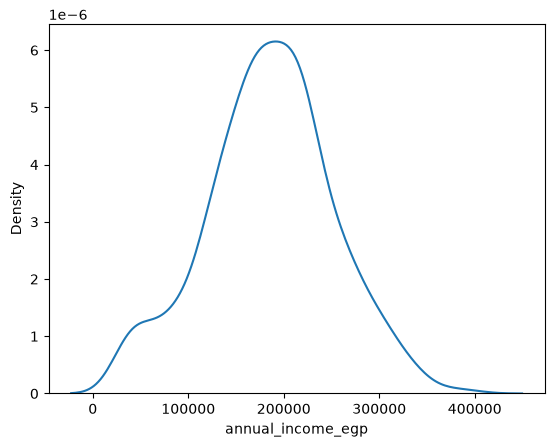

In [26]:
plt.figure()
sns.kdeplot(data=cleaned_data, x='annual_income_egp')
plt.show()

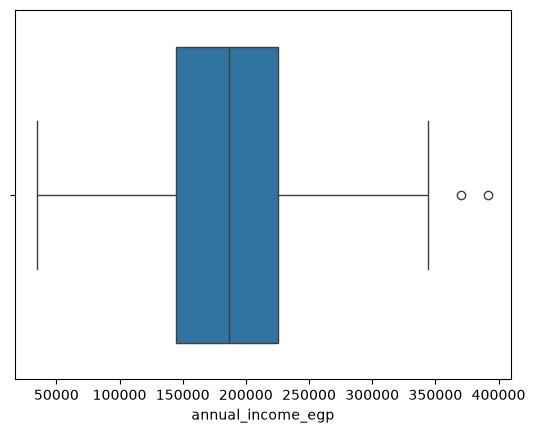

In [27]:
plt.figure()
sns.boxplot(data=cleaned_data, x='annual_income_egp')
plt.show()

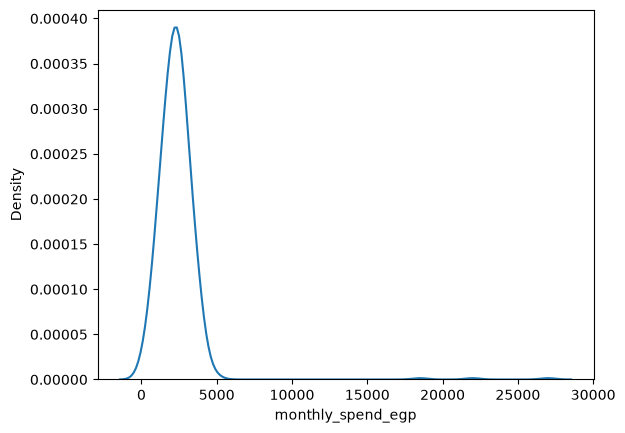

In [28]:
plt.figure()
sns.kdeplot(data=cleaned_data, x='monthly_spend_egp')
plt.show()

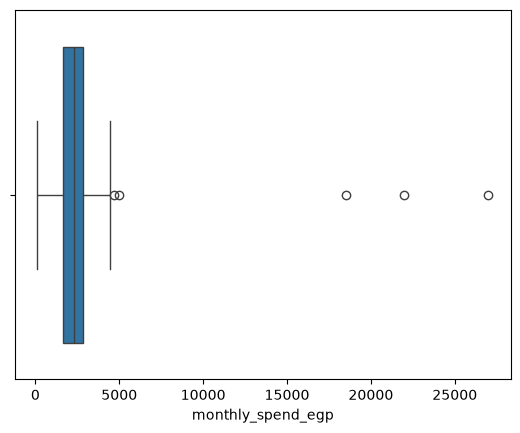

In [29]:
plt.figure()
sns.boxplot(data=cleaned_data, x='monthly_spend_egp')
plt.show()

In [30]:
cleaned_data[cleaned_data['monthly_spend_egp'] > 6000]

,customer_id,signup_date,region,acquisition_channel,segment,age,annual_income_egp,monthly_spend_egp,orders_last_6m,avg_order_value_egp,satisfaction_score,support_tickets,discount_rate,website_visits_last_30d,is_active,churned
61,CUST-10061,2023-12-06,NaN,Mobile App,Bronze,18,159801.0,18500.0,4,282.01,2.8,1,0.17,12,Yes,No
364,CUST-10364,2024-04-25,Alexandria,Branch,Bronze,50,153931.0,22000.0,3,446.41,4.5,1,0.06,14,No,No
483,CUST-10483,2025-03-01,Cairo,Branch,Bronze,56,35000.0,27000.0,7,501.59,3.9,6,0.01,21,Yes,Yes


In [160]:
cleaned_data.loc[[61,364,483],'monthly_spend_egp'] =2700

In [31]:
q1,q3 = df['monthly_spend_egp'].quantile([0.25,0.75])
iqr = q3-q1
lower , upper = q1-1.5*iqr , q3+1.5*iqr

In [32]:
print(lower)
print(upper)

-65.41249999999968
4570.3075


In [33]:
x = cleaned_data[cleaned_data['monthly_spend_egp'] > upper].index.tolist()
x

[23, 57, 61, 364, 483]

In [34]:
cleaned_data.loc[x , 'monthly_spend_egp' ] = upper

In [35]:
cleaned_data['is_active'].value_counts()

is_active
Yes    403
No     117
Name: count, dtype: int64

In [36]:
cleaned_data['churned'].value_counts()

churned
No     382
Yes    138
Name: count, dtype: int64

In [37]:
cols = cleaned_data.select_dtypes('str').columns.tolist()

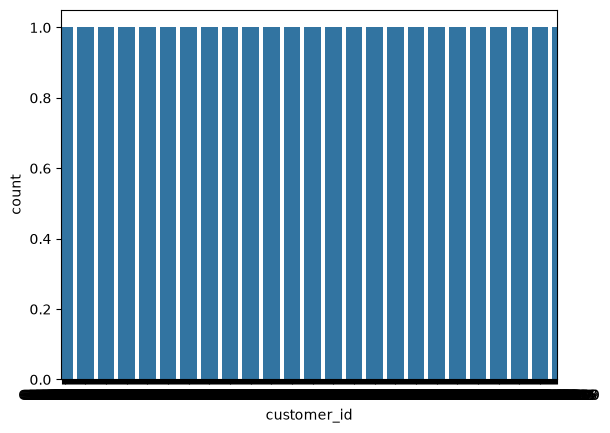

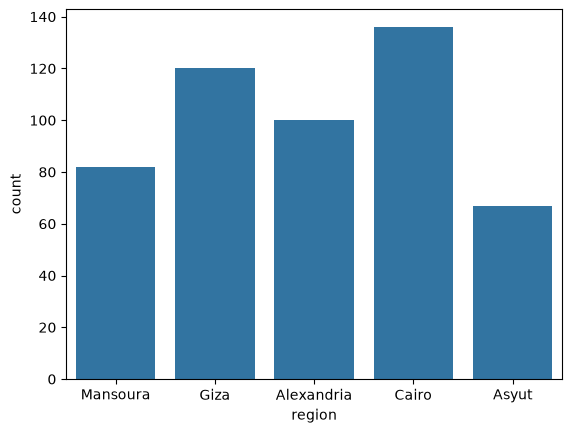

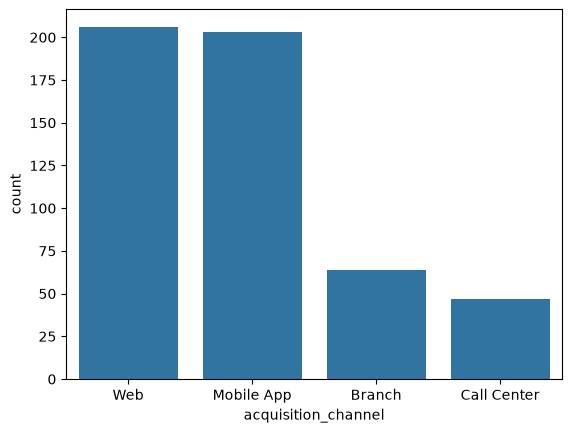

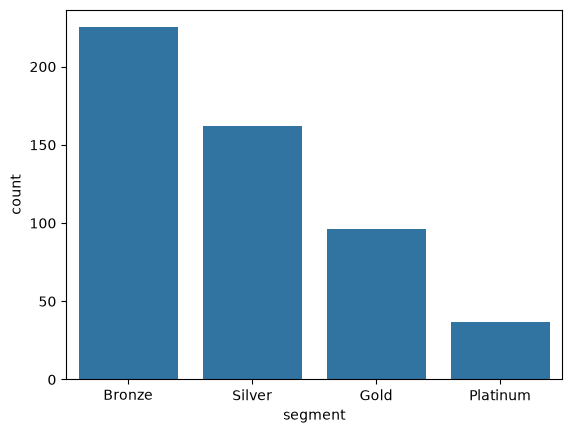

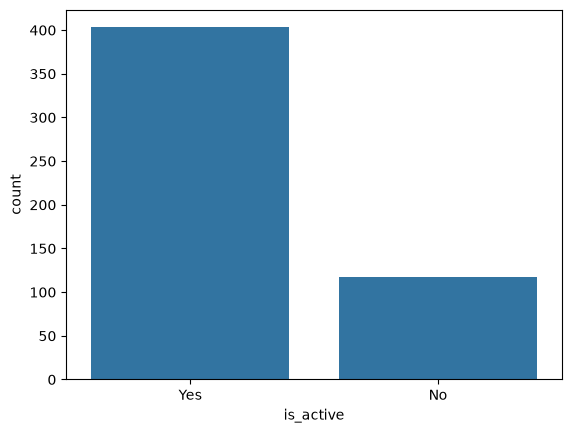

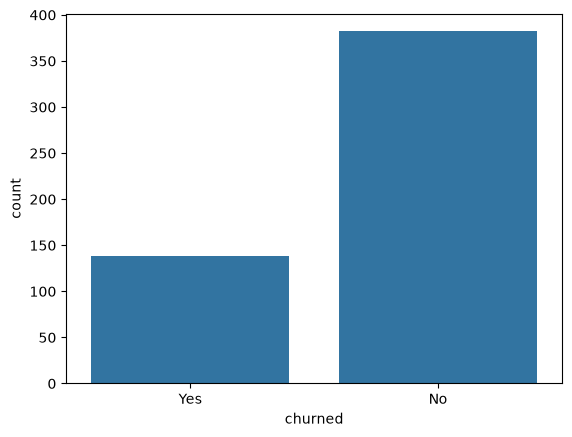

In [182]:
for i in cols :
    sns.countplot(data=cleaned_data , x=i)
    plt.show()

In [ ]:
cols = cleaned_data.select_dtypes('int','float').columns.tolist()

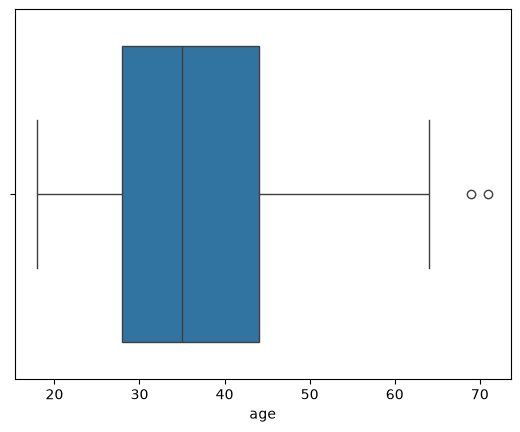

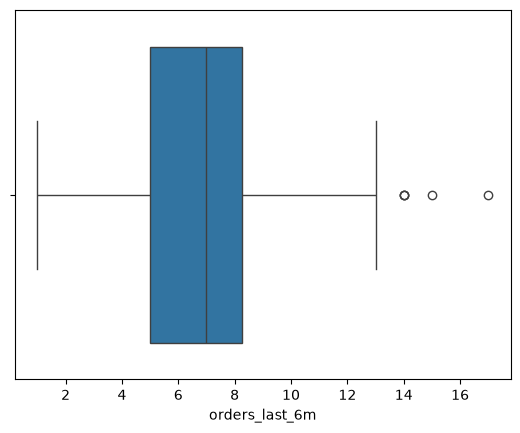

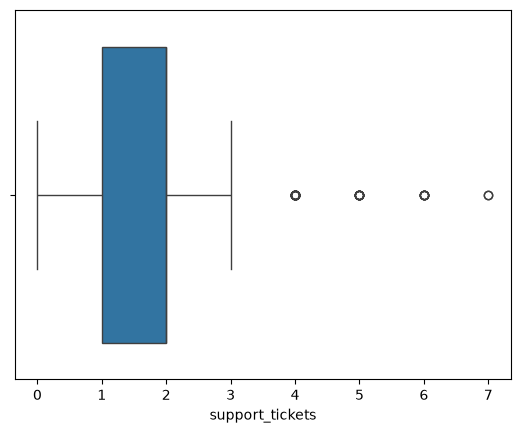

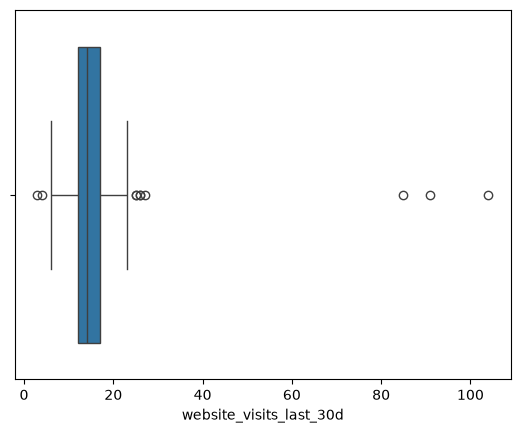

In [189]:
for i in cols :
    sns.boxplot(data=cleaned_data , x=i)
    plt.show()

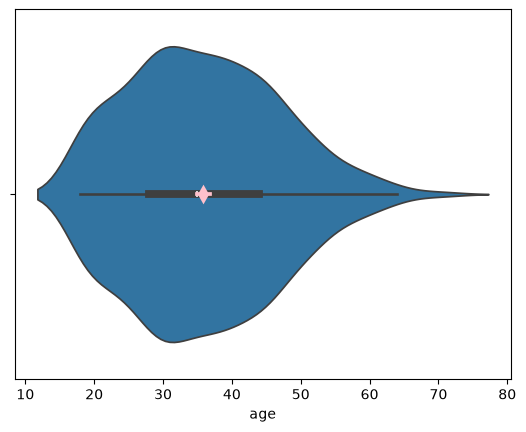

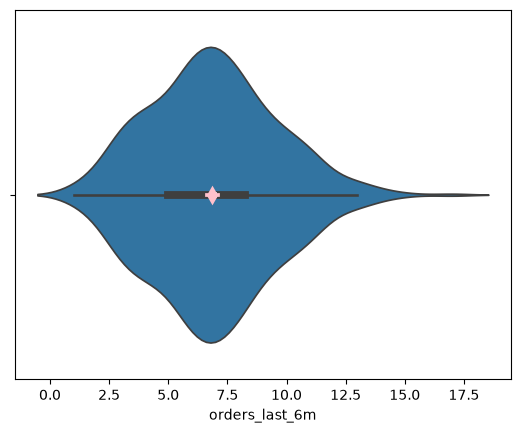

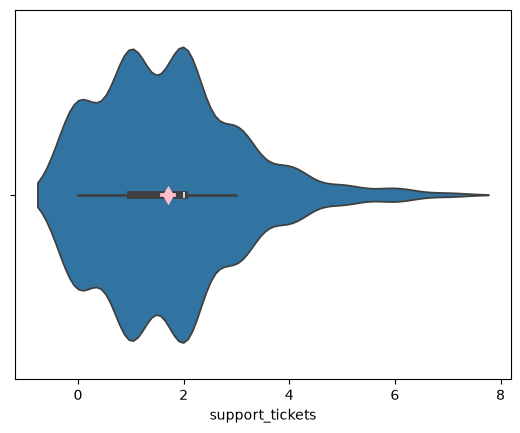

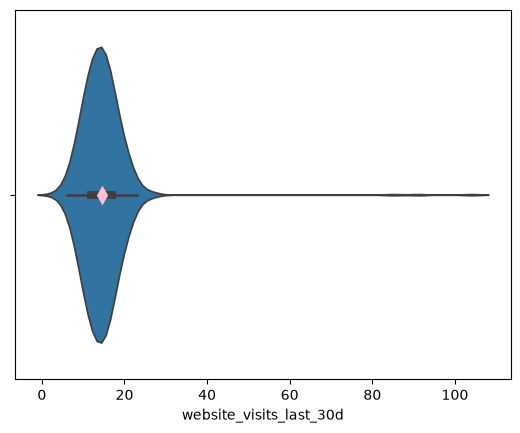

In [197]:
for i in cols :
    sns.violinplot(data=cleaned_data , x=i)
    sns.pointplot(data=cleaned_data , x=i , estimator=np.mean ,markers='d',
                  color='pink')
    plt.show()

In [39]:
cleaned_data.info()
cleaned_data.shape

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_id              520 non-null    str           
 1   signup_date              510 non-null    datetime64[us]
 2   region                   505 non-null    str           
 3   acquisition_channel      520 non-null    str           
 4   segment                  520 non-null    str           
 5   age                      520 non-null    int64         
 6   annual_income_egp        489 non-null    float64       
 7   monthly_spend_egp        520 non-null    float64       
 8   orders_last_6m           520 non-null    int64         
 9   avg_order_value_egp      500 non-null    float64       
 10  satisfaction_score       494 non-null    float64       
 11  support_tickets          520 non-null    int64         
 12  discount_rate            520 non-null    float6

(520, 16)

In [44]:
cleaned_data[cleaned_data['signup_date'].isna()]

,customer_id,signup_date,region,acquisition_channel,segment,age,annual_income_egp,monthly_spend_egp,orders_last_6m,avg_order_value_egp,satisfaction_score,support_tickets,discount_rate,website_visits_last_30d,is_active,churned
1,CUST-10001,NaT,Mansoura,Mobile App,Silver,64,232796.0,2558.02,7,409.97,4.6,3,0.10,18,Yes,No
36,CUST-10036,NaT,Giza,Web,Bronze,41,35000.0,2907.89,11,253.94,3.9,2,0.10,17,Yes,Yes
173,CUST-10173,NaT,Asyut,Mobile App,Silver,35,206119.0,2139.81,5,376.05,4.5,1,0.24,16,Yes,No
212,CUST-10212,NaT,Mansoura,Mobile App,Bronze,28,211967.0,386.31,7,50.00,3.7,2,0.30,11,No,No
221,CUST-10221,NaT,Mansoura,Web,Bronze,22,251703.0,1054.93,10,113.24,4.7,1,0.04,14,Yes,No
260,CUST-10260,NaT,Mansoura,Mobile App,Gold,22,124494.0,3858.39,5,632.51,3.7,1,0.35,10,Yes,No
298,CUST-10298,NaT,Cairo,Mobile App,Bronze,18,154055.0,4476.61,4,910.39,3.5,0,0.43,13,Yes,No
308,CUST-10308,NaT,Giza,Web,Bronze,34,168251.0,1627.34,8,236.23,4.5,2,0.06,20,No,No
470,CUST-10470,NaT,Cairo,Web,Platinum,28,200037.0,3544.83,8,397.37,3.9,4,0.26,9,Yes,No
505,CUST-10505,NaT,Alexandria,Web,Bronze,41,182485.0,1352.12,4,313.22,3.4,3,0.16,13,No,No


In [46]:
cleaned_data= cleaned_data[cleaned_data['signup_date'].notna()]

In [47]:
cleaned_data.info()

<class 'pandas.DataFrame'>
Index: 510 entries, 0 to 519
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_id              510 non-null    str           
 1   signup_date              510 non-null    datetime64[us]
 2   region                   495 non-null    str           
 3   acquisition_channel      510 non-null    str           
 4   segment                  510 non-null    str           
 5   age                      510 non-null    int64         
 6   annual_income_egp        479 non-null    float64       
 7   monthly_spend_egp        510 non-null    float64       
 8   orders_last_6m           510 non-null    int64         
 9   avg_order_value_egp      490 non-null    float64       
 10  satisfaction_score       484 non-null    float64       
 11  support_tickets          510 non-null    int64         
 12  discount_rate            510 non-null    float64    

In [49]:
cleaned_data['signup_date'].isna().sum()

np.int64(0)

In [60]:
cleaned_data[ cleaned_data['region'].isna() ]

,customer_id,signup_date,region,acquisition_channel,segment,age,annual_income_egp,monthly_spend_egp,orders_last_6m,avg_order_value_egp,satisfaction_score,support_tickets,discount_rate,website_visits_last_30d,is_active,churned
57,CUST-10057,2023-08-30,NaN,Web,Bronze,43,307705.0,4570.3075,4,1298.37,3.5,7,0.42,8,Yes,No
61,CUST-10061,2023-12-06,NaN,Mobile App,Bronze,18,159801.0,4570.3075,4,282.01,2.8,1,0.17,12,Yes,No
104,CUST-10104,2023-02-10,NaN,Call Center,Bronze,38,199363.0,2514.9000,15,183.68,2.5,1,0.18,13,No,No
127,CUST-10127,2023-05-15,NaN,Mobile App,Bronze,35,207070.0,1141.3300,17,79.55,2.6,2,0.18,13,Yes,No
128,CUST-10128,2023-07-20,NaN,Mobile App,Silver,36,199568.0,1231.1800,11,108.70,2.7,1,0.21,9,Yes,No
225,CUST-10225,2024-05-24,NaN,Mobile App,Silver,32,243905.0,2218.4900,5,427.06,4.7,1,0.21,15,Yes,No
290,CUST-10290,2024-09-02,NaN,Web,Silver,18,227929.0,1576.3100,5,355.07,3.1,2,0.38,10,Yes,Yes
313,CUST-10313,2023-04-30,NaN,Mobile App,Gold,43,245720.0,3098.9300,10,345.16,3.8,4,0.37,10,Yes,No
368,CUST-10368,2024-06-30,NaN,Web,Silver,33,269345.0,225.1800,12,50.00,2.1,0,0.32,14,No,Yes
378,CUST-10378,2024-01-08,NaN,Mobile App,Bronze,35,86106.0,1565.4700,10,181.10,4.1,0,0.18,11,No,Yes


In [58]:
cleaned_data['region'].value_counts()

region
Cairo         134
Giza          118
Alexandria     99
Mansoura       78
Asyut          66
Name: count, dtype: int64

In [71]:
cleaned_data.groupby('region')['age'].mean().reset_index()


,region,age
0,Alexandria,37.080808
1,Asyut,34.212121
2,Cairo,36.701493
3,Giza,34.338983
4,Mansoura,36.923077


In [72]:
cleaned_data.groupby('region')['age'].std().reset_index()

,region,age
0,Alexandria,11.076429
1,Asyut,10.548810
2,Cairo,10.768256
3,Giza,10.335583
4,Mansoura,11.663874


In [80]:
mode = cleaned_data['region'].value_counts().reset_index().loc[0]['region']

In [87]:
cleaned_data['region'] = cleaned_data['region'].fillna(mode)

In [88]:
cleaned_data.info()

<class 'pandas.DataFrame'>
Index: 510 entries, 0 to 519
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_id              510 non-null    str           
 1   signup_date              510 non-null    datetime64[us]
 2   region                   510 non-null    str           
 3   acquisition_channel      510 non-null    str           
 4   segment                  510 non-null    str           
 5   age                      510 non-null    int64         
 6   annual_income_egp        479 non-null    float64       
 7   monthly_spend_egp        510 non-null    float64       
 8   orders_last_6m           510 non-null    int64         
 9   avg_order_value_egp      490 non-null    float64       
 10  satisfaction_score       484 non-null    float64       
 11  support_tickets          510 non-null    int64         
 12  discount_rate            510 non-null    float64    

In [90]:
cleaned_data.groupby('segment')['annual_income_egp'].mean().reset_index()

,segment,annual_income_egp
0,Bronze,181984.990521
1,Gold,179083.215054
2,Platinum,205834.911765
3,Silver,190319.808511


In [ ]:
#fill every non in (annual income) ---> mean of segment

In [94]:
cleaned_data[cleaned_data['annual_income_egp'].isna()]

,customer_id,signup_date,region,acquisition_channel,segment,age,annual_income_egp,monthly_spend_egp,orders_last_6m,avg_order_value_egp,satisfaction_score,support_tickets,discount_rate,website_visits_last_30d,is_active,churned


In [93]:
cleaned_data['annual_income_egp']=cleaned_data['annual_income_egp'].fillna(
    cleaned_data.groupby('segment')['annual_income_egp'].transform('mean')
)

In [95]:
cleaned_data.loc[14]

customer_id                         CUST-10014
signup_date                2024-01-08 00:00:00
region                              Alexandria
acquisition_channel                Call Center
segment                                 Silver
age                                         28
annual_income_egp                190319.808511
monthly_spend_egp                      3023.88
orders_last_6m                               9
avg_order_value_egp                     350.58
satisfaction_score                         2.7
support_tickets                              1
discount_rate                             0.16
website_visits_last_30d                     16
is_active                                  Yes
churned                                    Yes
Name: 14, dtype: object

In [96]:
cleaned_data.loc[90]

customer_id                         CUST-10090
signup_date                2023-09-09 00:00:00
region                                   Asyut
acquisition_channel                        Web
segment                                 Bronze
age                                         23
annual_income_egp                     220867.0
monthly_spend_egp                       2126.5
orders_last_6m                               4
avg_order_value_egp                     469.81
satisfaction_score                         2.9
support_tickets                              3
discount_rate                             0.17
website_visits_last_30d                     14
is_active                                  Yes
churned                                    Yes
Name: 90, dtype: object

In [97]:
cleaned_data.info()

<class 'pandas.DataFrame'>
Index: 510 entries, 0 to 519
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_id              510 non-null    str           
 1   signup_date              510 non-null    datetime64[us]
 2   region                   510 non-null    str           
 3   acquisition_channel      510 non-null    str           
 4   segment                  510 non-null    str           
 5   age                      510 non-null    int64         
 6   annual_income_egp        510 non-null    float64       
 7   monthly_spend_egp        510 non-null    float64       
 8   orders_last_6m           510 non-null    int64         
 9   avg_order_value_egp      490 non-null    float64       
 10  satisfaction_score       484 non-null    float64       
 11  support_tickets          510 non-null    int64         
 12  discount_rate            510 non-null    float64    

In [98]:
cleaned_data.drop(columns=['satisfaction_score'],inplace=True)

In [99]:
cleaned_data.info()

<class 'pandas.DataFrame'>
Index: 510 entries, 0 to 519
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_id              510 non-null    str           
 1   signup_date              510 non-null    datetime64[us]
 2   region                   510 non-null    str           
 3   acquisition_channel      510 non-null    str           
 4   segment                  510 non-null    str           
 5   age                      510 non-null    int64         
 6   annual_income_egp        510 non-null    float64       
 7   monthly_spend_egp        510 non-null    float64       
 8   orders_last_6m           510 non-null    int64         
 9   avg_order_value_egp      490 non-null    float64       
 10  support_tickets          510 non-null    int64         
 11  discount_rate            510 non-null    float64       
 12  website_visits_last_30d  510 non-null    int64      

In [103]:
cleaned_data['avg_order_value_egp'] = cleaned_data['avg_order_value_egp'].fillna(cleaned_data['avg_order_value_egp'].mean())

In [104]:
cleaned_data.info()

<class 'pandas.DataFrame'>
Index: 510 entries, 0 to 519
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_id              510 non-null    str           
 1   signup_date              510 non-null    datetime64[us]
 2   region                   510 non-null    str           
 3   acquisition_channel      510 non-null    str           
 4   segment                  510 non-null    str           
 5   age                      510 non-null    int64         
 6   annual_income_egp        510 non-null    float64       
 7   monthly_spend_egp        510 non-null    float64       
 8   orders_last_6m           510 non-null    int64         
 9   avg_order_value_egp      510 non-null    float64       
 10  support_tickets          510 non-null    int64         
 11  discount_rate            510 non-null    float64       
 12  website_visits_last_30d  510 non-null    int64      

In [106]:
cleaned_data.to_csv('Asmaa.csv',index=False)